<h1>M Riziq Sirfatullah Alfarizi <br>
i.2211266 </h1>

# T-SNE (t-Distributed Stochastic Neighbor Embedding)


merupakan teknik untuk reduksi dimensi yang digunkan untuk memvisualisasikan data berdimensi tinggi dalam 2 atau 3 dimensi

Karakterisasi T-SNE:
1. cocok untuk data non-linear dengan pola kompleks.
2. hanya untuk visualisasi 2 dimensi atau 3 dimensi, hasil tidak dapat digunakan untuk perhitungan atau interpretasi lanjutan.
3. kecepatan lebih lambat karena memerlukan optimasi berbasis gradien untuk setiap iterasi
4. lebih baik dari PCA dalam memvisualisasikan data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kingabzpro/cosmetics-datasets")

print("Path to dataset files:", path)

100%|██████████| 263k/263k [00:00<00:00, 57.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kingabzpro/cosmetics-datasets/versions/1


In [4]:
import os
dataset_path = '/root/.cache/kagglehub/datasets/kingabzpro/cosmetics-datasets/versions/1'
files = os.listdir(dataset_path)
print('Nama Files: ', files)

Nama Files:  ['cosmetics.csv']


In [6]:
data_file = os.path.join(dataset_path, 'cosmetics.csv')
print('Path file: ', data_file)

Path file:  /root/.cache/kagglehub/datasets/kingabzpro/cosmetics-datasets/versions/1/cosmetics.csv


In [8]:
import pandas as pd

data = pd.read_csv(data_file)
data.head(5)

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Label        1472 non-null   object 
 1   Brand        1472 non-null   object 
 2   Name         1472 non-null   object 
 3   Price        1472 non-null   int64  
 4   Rank         1472 non-null   float64
 5   Ingredients  1472 non-null   object 
 6   Combination  1472 non-null   int64  
 7   Dry          1472 non-null   int64  
 8   Normal       1472 non-null   int64  
 9   Oily         1472 non-null   int64  
 10  Sensitive    1472 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 126.6+ KB


In [10]:
data.columns

Index(['Label', 'Brand', 'Name', 'Price', 'Rank', 'Ingredients', 'Combination',
       'Dry', 'Normal', 'Oily', 'Sensitive'],
      dtype='object')

In [12]:
data['Combination'].unique()

array([1, 0])

In [26]:
data['Normal'].unique()

array([1, 0])

In [15]:
x = data[['Price', 'Rank', 'Combination', 'Dry', 'Oily', 'Sensitive']]
y = data['Normal']

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Visualisasi menggunakan PCA 2 Dimensi

In [19]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Covert ke dalam dataframe untuk visualisasi

pca_df = pd.DataFrame(x_pca, columns=['Components 1', 'Components 2'])
pca_df['Label'] = y

pca_df.head()

,Components 1,Components 2,Label
0,119.416118,0.742397,1
1,123.416117,0.740505,1
2,12.415962,0.325485,1
3,119.416225,0.729592,1
4,-17.583837,0.807169,1


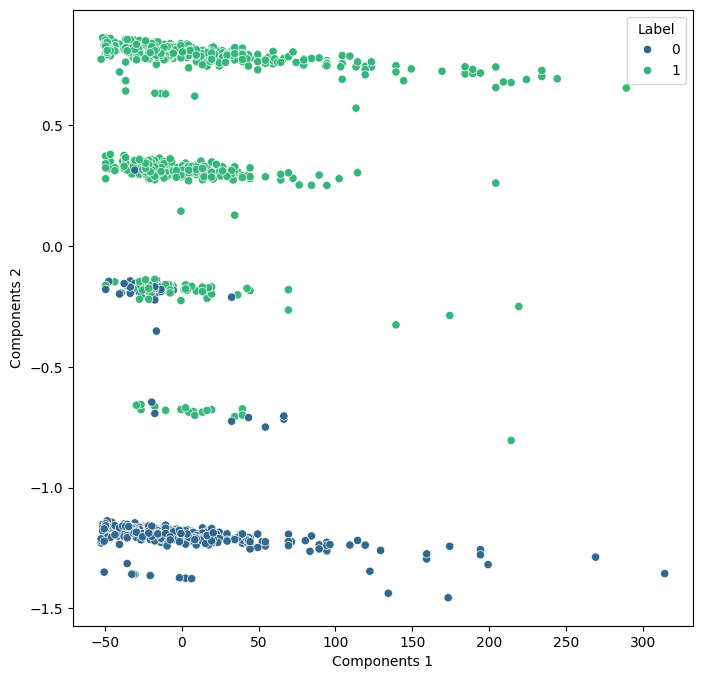

In [20]:
# Hasil Plot menggunakan PCA

plt.figure(figsize=(8,8))
sns.scatterplot(data = pca_df, x = 'Components 1', y = 'Components 2', hue = 'Label', palette = 'viridis')
plt.xlabel('Components 1')
plt.ylabel('Components 2')
plt.show()

# Visualisasi Menggunakan t-SNE 2 Dimensi

In [21]:
from sklearn.manifold import TSNE

In [24]:
tsne = TSNE(n_components=2, random_state=0, perplexity=50)
x_tsne = tsne.fit_transform(x)

# Covert ke dalam dataframe untuk visualisasi

tsne_df = pd.DataFrame(x_tsne, columns=['Components 1', 'Components 2'])
tsne_df['Label'] = y

tsne_df.head()

,Components 1,Components 2,Label
0,46.728962,-12.565241,1
1,46.871315,-12.862928,1
2,21.692677,17.031710,1
3,46.727127,-12.566023,1
4,-8.659594,-4.820535,1


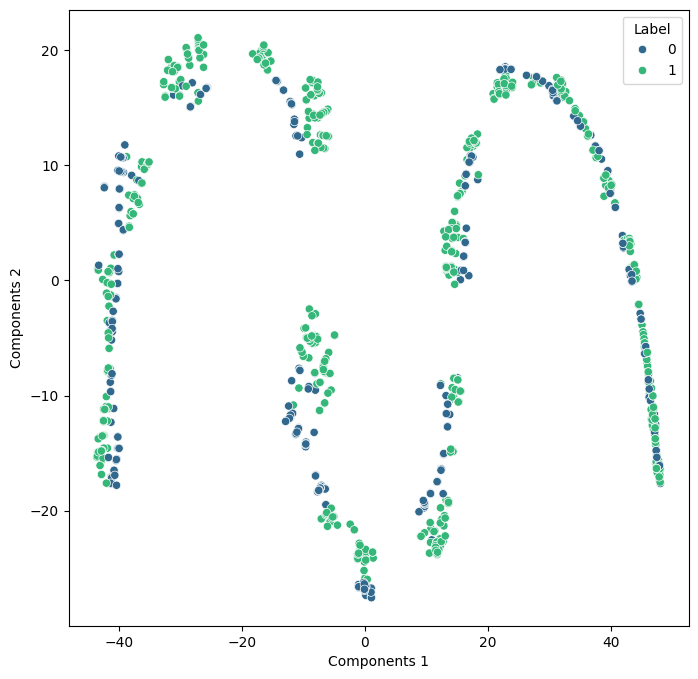

In [25]:
# Hasil Plot menggunakan TSNE

plt.figure(figsize=(8,8))
sns.scatterplot(data = tsne_df, x = 'Components 1', y = 'Components 2', hue = 'Label', palette = 'viridis')
plt.xlabel('Components 1')
plt.ylabel('Components 2')
plt.show()

<h1> Kesimpulan:

Berdasarkan visualisasi tersebut, data kulit normal menyesuaikan dengan Component 1 dan 2, sehingga data input x ('Price', 'Rank', 'Combination', 'Dry', 'Oily', 'Sensitive') sebanding untuk kulit normal dan tidak normal

<h1> apa itu Perplexity?

Perplexity merupakan parameter dalam t-SNE yang berfungsi untuk mengontrol hubungan lokal dalam data, jadi Perplexity menentukan jumlah tetangga efektif yang dipertimbangkan oleh Algoritmannya

- nilai Perplexity rendah (Misalkan = 5-30) akan berfokus pada struktur lokalnya saja
- nilai Perplexity tinggi akan menghitung hubungan yg lebih luas, sehingga pola global mungkin lebih dominan

<h3> Rekomendasi penentuan nilai Perplexity:

- Dataset kecil: Perplexity kecil (5-15)
- Dataset besar: Perplexity besae (30-50)


# Visualisasi 3 Dimensi menggunakan PCA

In [27]:
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x)

# Covert ke dalam dataframe untuk visualisasi

pca_df = pd.DataFrame(x_pca, columns=['Components 1', 'Components 2', 'Components 3'])
pca_df['Label'] = y

pca_df.head()

,Components 1,Components 2,Components 3,Label
0,119.416118,0.742397,-0.044213,1
1,123.416117,0.740505,-0.042719,1
2,12.415962,0.325485,0.244216,1
3,119.416225,0.729592,-0.343916,1
4,-17.583837,0.807169,-0.095394,1


In [30]:
from mpl_toolkits.mplot3d import Axes3D

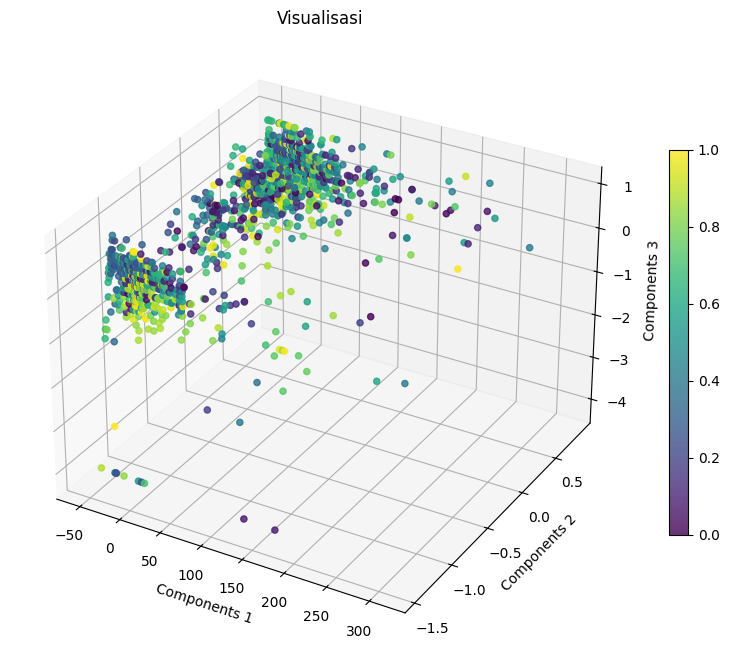

In [34]:
# Visualisasi Hasil PCA dalam 3 Dimensi
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pca_df['Components 1'], pca_df['Components 2'], pca_df['Components 3'],
                c = np.linspace(0,1, len(pca_df)), cmap='viridis', alpha = 0.8)
plt.colorbar(sc, ax = ax, shrink=0.5)
ax.set_title('Visualisasi')
ax.set_xlabel('Components 1')
ax.set_ylabel('Components 2')
ax.set_zlabel('Components 3')
plt.show()

In [37]:
pca_df

,Components 1,Components 2,Components 3,Label
0,119.416118,0.742397,-0.044213,1
1,123.416117,0.740505,-0.042719,1
2,12.415962,0.325485,0.244216,1
3,119.416225,0.729592,-0.343916,1
4,-17.583837,0.807169,-0.095394,1
...,...,...,...,...
1467,-20.583765,0.800051,-0.296316,1
1468,-7.584632,-1.216576,-0.505356,0
1469,-1.584599,-1.223680,-0.603015,0
1470,-35.583700,-1.314309,-3.113238,0


In [40]:
import plotly.graph_objects as go

# Membuat plot 3D
fig = go.Figure(
    data = [
        go.Scatter3d(
            x = pca_df['Components 1'],
            y = pca_df['Components 2'],
            z = pca_df['Components 3'],
            mode = 'markers',
            marker = dict(
                size = 5,
                color = pca_df['Label'],
                opacity = 0.5,
                colorscale='Spectral',
                colorbar = dict(title='Color Legend')
            )
        )
    ]
)


fig.update_layout(
    width = 800,
    height = 800,
    plot_bgcolor = 'rgba(0, 0, 0, 0)',
    title = dict(
        text = '<b>Visualisasi PCA</b>',
        font = dict(
            size = 20
        )
    ),
    scene = dict(
        xaxis_title = 'Components 1',
        yaxis_title = 'Components 2',
        zaxis_title = 'Components 3',
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False),
        zaxis=dict(showgrid=False)
    )
)

# Tampilkan plot
fig.show()

# Visualisasi 3 Dimensi menggunakan TSNE

In [43]:
tsne = TSNE(n_components=3, random_state= 0, perplexity=50 )
x_tsne = tsne.fit_transform(x)

# Covert ke dalam dataframe untuk visualisasi

tsne_df = pd.DataFrame(x_tsne, columns=['Components 1', 'Components 2', 'Components 3'])
tsne_df['Label'] = y

tsne_df.head()

,Components 1,Components 2,Components 3,Label
0,17.846882,0.388743,5.403050,1
1,18.113506,0.465229,5.451580,1
2,7.789948,8.009481,-1.173333,1
3,17.979097,0.144883,5.403244,1
4,-3.005986,-1.526679,-7.590423,1


In [44]:
from mpl_toolkits.mplot3d import Axes3D

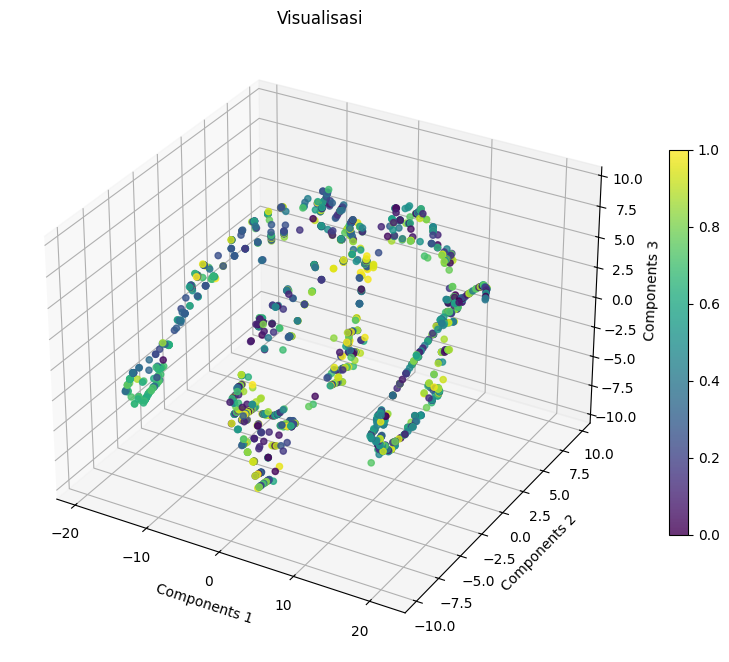

In [46]:
# Visualisasi Hasil TSNE dalam 3 Dimensi
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(tsne_df['Components 1'], tsne_df['Components 2'], tsne_df['Components 3'],
                c = np.linspace(0,1, len(tsne_df)), cmap='viridis', alpha = 0.8)
plt.colorbar(sc, ax = ax, shrink=0.5)
ax.set_title('Visualisasi')
ax.set_xlabel('Components 1')
ax.set_ylabel('Components 2')
ax.set_zlabel('Components 3')
plt.show()

In [48]:
import plotly.graph_objects as go

# Membuat plot 3D
fig = go.Figure(
    data = [
        go.Scatter3d(
            x = tsne_df['Components 1'],
            y = tsne_df['Components 2'],
            z = tsne_df['Components 3'],
            mode = 'markers',
            marker = dict(
                size = 5,
                color = tsne_df['Label'],
                opacity = 0.5,
                colorscale='Spectral',
                colorbar = dict(title='Color Legend')
            )
        )
    ]
)


fig.update_layout(
    width = 800,
    height = 800,
    plot_bgcolor = 'rgba(0, 0, 0, 0)',
    title = dict(
        text = '<b>Visualisasi TSNE</b>',
        font = dict(
            size = 20
        )
    ),
    scene = dict(
        xaxis_title = 'Components 1',
        yaxis_title = 'Components 2',
        zaxis_title = 'Components 3',
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False),
        zaxis=dict(showgrid=False)
    )
)

# Tampilkan plot
fig.show()

In [54]:
import plotly.express as px
# Visualisasi Hasil TSNE dalam 3 Dimensi

fig = px.scatter_3d(tsne_df, x = 'Components 1', y = 'Components 2', z = 'Components 3',
                color = np.linspace(0,1, len(tsne_df)), color_continuous_scale='viridis', title = 'Visualisasi TSNE 3D')
# ax.set_title('Visualisasi')
# ax.set_xlabel('Components 1')
# ax.set_ylabel('Components 2')
# ax.set_zlabel('Components 3')
fig.show()